Import Libraries :____________________________________________________________________________________________________________________________________________________________________________________

In [79]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_recall_fscore_support

Deciding which device I should use. I used CPU instead of GPU because my python version is 3.14 and pythorch is not fully ready for this new version. To use GPU 3.10,3.11 python is needed.

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
print("Using device:", device)

Using device: cpu


Load and explore dataset :____________________________________________________________________________________________________________________________________________________________________________

loaded the dataset(used a simple data set of cat and dog images).










In [33]:

source_dir = r"C:\Users\User\Documents\Spring25-26\CVPR\Mid\Mid_Assignment\PetImages"
print("Top-level folders/files:")
print(os.listdir(source_dir))


Top-level folders/files:
['Cat', 'Dog']


Checked how many classed the dataset contains 

In [34]:
classes = [d for d in os.listdir(source_dir) 
           if os.path.isdir(os.path.join(source_dir, d))]

print("Total classes:", len(classes))

Total classes: 2


Checked how many sample images each folder contains.

In [35]:
for class_name in classes:
    class_path = os.path.join(source_dir, class_name)
    num_images = len(os.listdir(class_path))
    print(f"{class_name}: {num_images}")

Cat: 12499
Dog: 12499


Data Preprocessing and Augmentation :________________________________________________________________________________________________________________________________________________________________

The data set is splited in tran directory, validation directory and test directory

In [46]:
base_dir = "dataset"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

for split in [train_dir, val_dir, test_dir]:
    os.makedirs(split, exist_ok=True)

for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = [img for img in os.listdir(class_path)
          if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)

    train_split = int(0.7 * len(images))
    val_split   = int(0.85 * len(images))

    splits = {
        train_dir: images[:train_split],
        val_dir: images[train_split:val_split],
        test_dir: images[val_split:]
    }

    for split_dir, split_images in splits.items():
        class_split_path = os.path.join(split_dir, class_name)
        os.makedirs(class_split_path, exist_ok=True)

        for img in split_images:
            src = os.path.join(class_path, img)
            dst = os.path.join(class_split_path, img)
            shutil.copyfile(src, dst)

print("Dataset split complete!")

Dataset split complete!


Check for the corrupted image files 

In [ ]:
for i in range(len(train_loader.dataset)):
    try:
        img, label = train_loader.dataset[i]
    except Exception as e:
        print("Broken sample index:", i) #check the broken or corrupted image file 
        print("Error:", e) #check for any type of error
        break

Broken sample index: 0
Error: 'tuple' object cannot be interpreted as an integer


adding corrupted image handler

In [47]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True #Protection from corrupted image

Setting up image dataset pipeline in pytorch for traning. 

Augmentaiton for only traing data. No augmentation for tesing and validation data because they must represent the real and unchanged data.

In [ ]:
IMG_SIZE = 224 #standerd input size
BATCH_SIZE = 32 #number of images processed at once during traing

#data augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), #making all images same size
    transforms.RandomHorizontalFlip(), #helps medel generalize image can apper flipped
    transforms.RandomRotation(15), #makes model robast for small rotation
    transforms.ToTensor() #converts images to pytorch tensor
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder("dataset/train", transform=train_transform)
val_data   = datasets.ImageFolder("dataset/val", transform=val_transform)
test_data  = datasets.ImageFolder("dataset/test", transform=val_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True) # suffling train data for preventing learning order bias
val_loader   = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE)

class_names = train_data.classes 

print("Num of Classes:", len(class_names))

Num of Classes: 2


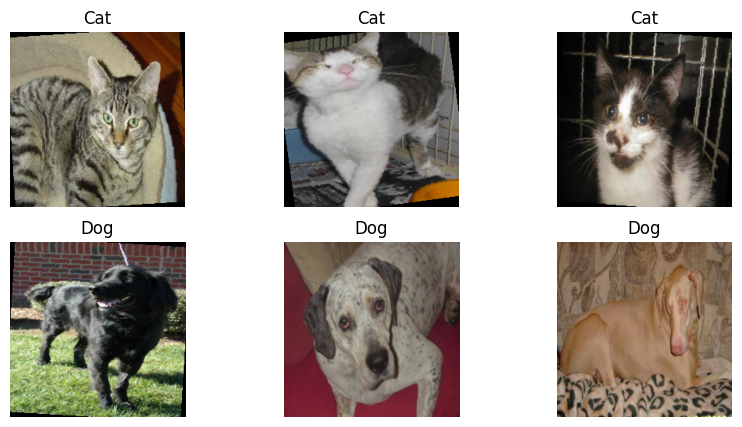

In [64]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

Definig CNN architecture :____________________________________________________________________________________________________________________________________________________________________________

With batch normalization and dropout for regularization

In [ ]:
class CNN_WithReg(nn.Module): #in pytorch, all models must inherit from nn.Module
    def __init__(self, num_classes): #init constructor initialize the model 
        super().__init__()

        self.features = nn.Sequential(  #extracts patterns from images
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential( #Converts extracted features into final predictions
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x): #how data flows through the network
        x = self.features(x)
        x = self.classifier(x)
        return x



In [ ]:
model_with_reg = CNN_WithReg(num_classes=len(class_names)).to(device) #creating CNN model and preparing it to run on your hardware
print(model_with_reg)

CNN_WithReg(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dr

Without batch normalization and dropout for regularization

In [67]:
class CNN_WithoutReg(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [68]:
model_without_reg = CNN_WithoutReg(num_classes=len(class_names)).to(device)
print(model_without_reg)

CNN_WithoutReg(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=2, bias=True)
  )
)


Training Loop with Validation :____________________________________________________________________________________________________________________________________________________________________________

Used CrossEntropyLoss() for multi class classification and Adam as optimizer.

Used learning rate scheduler that helps to avoid overshooting minimum and improve convergence in later stages.

In [ ]:
criterion = nn.CrossEntropyLoss() #CrossEntropyLoss is used for multi-class classification.
optimizer = optim.Adam(model_with_reg.parameters(), lr=0.001) #Adam adapts learning rate for each parameter

In [ ]:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
#Every 5 epoc LR becomes half

In [ ]:
EPOCHS = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):

    # -------- TRAINING --------
    model_with_reg.train()
    running_loss = 0 #initial tracking
    correct = 0
    total = 0

    for images, labels in train_loader: #Processes data in mini-batches
        images, labels = images.to(device), labels.to(device) #Ensures data and model are on same hardware (CPU/GPU)

        optimizer.zero_grad() #Prevents gradient accumulation from previous batch
        outputs = model_with_reg(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # -------- VALIDATION --------
    model_with_reg.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad(): #Saves memory & speeds up validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model_with_reg(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Step the scheduler
    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

c:\Users\User\Documents\Spring25-26\CVPR\Mid\Mid_Assignment\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
C:\Users\User\AppData\Local\Temp\ipykernel_29580\3983523761.py:64: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 1/10
Train Loss: 1.0353, Train Acc: 0.5860
Val Loss: 0.6201, Val Acc: 0.6491
Epoch 2/10
Train Loss: 0.6338, Train Acc: 0.6342
Val Loss: 0.5986, Val Acc: 0.6613
Epoch 3/10
Train Loss: 0.6037, Train Acc: 0.6666
Val Loss: 0.5430, Val Acc: 0.7317
Epoch 4/10
Train Loss: 0.5815, Train Acc: 0.6841
Val Loss: 0.5401, Val Acc: 0.7525
Epoch 5/10
Train Loss: 0.5638, Train Acc: 0.6950
Val Loss: 0.4594, Val Acc: 0.7904
Epoch 6/10
Train Loss: 0.5357, Train Acc: 0.7200
Val Loss: 0.4343, Val Acc: 0.7960
Epoch 7/10
Train Loss: 0.4966, Train Acc: 0.7545
Val Loss: 0.4884, Val Acc: 0.7987
Epoch 8/10
Train Loss: 0.4616, Train Acc: 0.7779
Val Loss: 0.4964, Val Acc: 0.8181
Epoch 9/10
Train Loss: 0.4332, Train Acc: 0.7949
Val Loss: 0.4137, Val Acc: 0.8213
Epoch 10/10
Train Loss: 0.3962, Train Acc: 0.8113
Val Loss: 0.3286, Val Acc: 0.8563


The loss curve indicates that both training and validation loss decrease steadily suggesting the model is learning effectively with a slight fluctuation in validation loss mid-training.

The accuracy curve shows consistent improvement for both training and validation accuracy with validation accuracy slightly higher than training. 

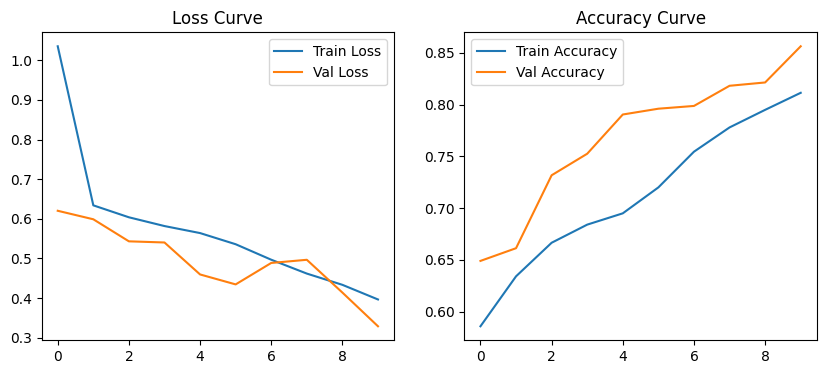

In [71]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

Printing the current learing rate 

In [72]:
print("Current LR:", scheduler.get_last_lr())

Current LR: [0.00025]


Evaluate Model on Test Set:__________________________________________________________________________________________________________________________________________________________________________

Accuracy = overall correct predictions

Precision = correctness of predicted class

Recall = ability to find all true samples

F1-score = balance between precision & recall


In [73]:
model_with_reg.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_with_reg(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Overall accuracy
accuracy = accuracy_score(all_labels, all_preds)
print("Test Accuracy:", accuracy)

# Detailed report
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)

Test Accuracy: 0.8533333333333334
              precision    recall  f1-score   support

         Cat     0.8877    0.8091    0.8465      1875
         Dog     0.8246    0.8976    0.8596      1875

    accuracy                         0.8533      3750
   macro avg     0.8561    0.8533    0.8530      3750
weighted avg     0.8561    0.8533    0.8530      3750



True Postive = Model predicted Positive, and it is actually Positive

True Negative = Model predicted Negative, and it is actually Negative

False Positive = Model predicted Positive, but it is actually Negative

False Negative = Model predicted Negative, but it is actually Positive


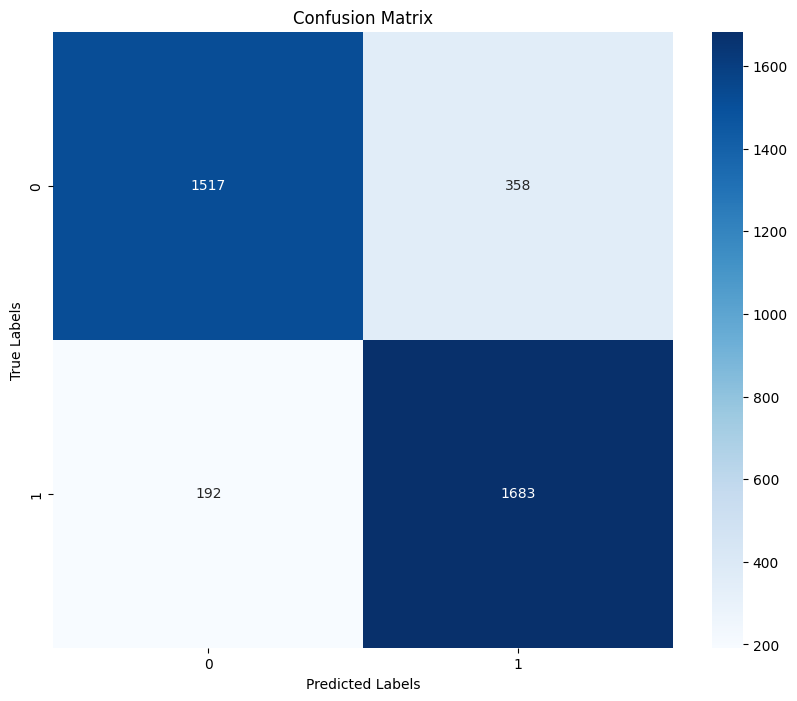

In [76]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

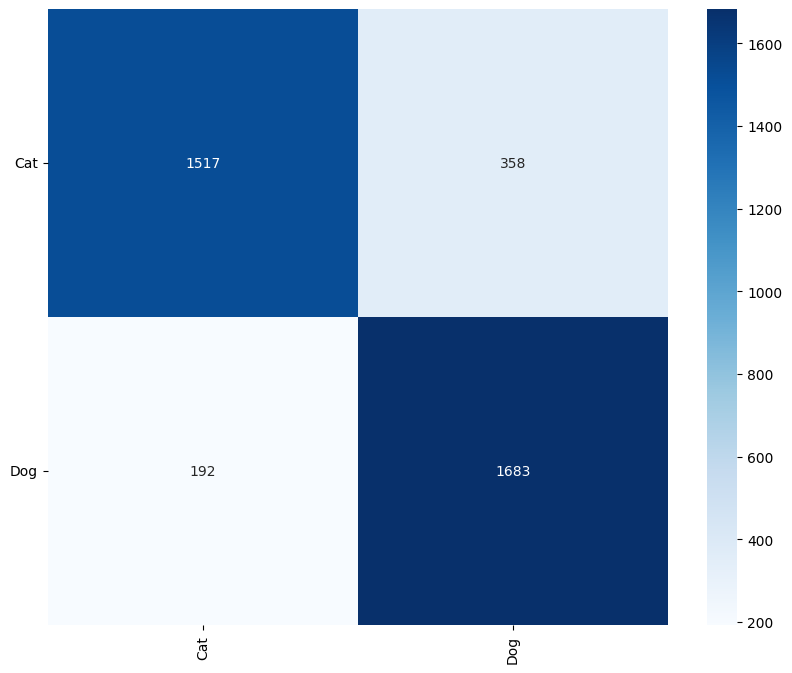

In [104]:
class_names = train_loader.dataset.classes

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [80]:
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds)

for i, class_name in enumerate(class_names):
    print(f"{class_name}: F1-score = {f1[i]:.4f}")

best_idx = np.argmax(f1)
worst_idx = np.argmin(f1)

print("Best Performing Class:", class_names[best_idx], "F1:", f1[best_idx])
print("Worst Performing Class:", class_names[worst_idx], "F1:", f1[worst_idx])

Cat: F1-score = 0.8465
Dog: F1-score = 0.8596
Best Performing Class: Dog F1: 0.8595505617977528
Worst Performing Class: Cat F1: 0.8465401785714286


In [81]:
torch.save(model_with_reg.state_dict(), "Final_model.pth")
print("Model saved successfully!")

Model saved successfully!


Analysis and Discussion of Results :_____________________________________________________________________________________________________________________________________________________________

The model was trained on the pet image dataset and evaluated using different performance metrics such as accuracy, precision, recall, and F1-score. Overall, the model showed good performance, which indicates that it was able to learn meaningful patterns from the images.From the training and validation curves, we can observe that the training loss decreased steadily over time, showing that the model was learning properly. The validation loss also followed a similar trend, although in some cases there was a slight gap between training and validation performance. This suggests that the model may have experienced a small amount of overfitting.From the confusion matrix and per-class analysis, it is clear that the model performs better on some classes than others. Classes with more distinct visual features were classified more accurately. On the other hand, classes with similar shapes or fewer training samples were more likely to be misclassified.

Conclusions & Future Work :_____________________________________________________________________________________________________________________________________________________________________

In this project, a custom Convolutional Neural Network (CNN) was successfully designed and trained for image classification using the Pet Image dataset. The model was able to achieve good performance, demonstrating the effectiveness of CNNs in solving computer vision problems. For future work, several improvements can be considered. First, using a larger dataset could help improve performance. Second, applying more advanced data augmentation techniques may help the model generalize better. Additionally, using pre-trained models (transfer learning) such as ResNet or VGG could significantly improve accuracy.
